In [25]:
import pandas as pd
import numpy as np
import os

In [26]:
from sklearn.model_selection import train_test_split


from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold,RandomizedSearchCV,GridSearchCV

from sklearn import metrics
from sklearn.feature_selection import SelectFromModel

import lightgbm as lgbm

In [27]:
data = pd.read_csv(os.getcwd()+"\\data\\data.csv")

In [28]:
data.shape

(320770, 1330)

Split onto train/test 

In [31]:
x, y = data.drop(['soldPrice'], axis = 1), data['soldPrice']

In [32]:
import re
x = x.rename(columns = lambda z: re.sub('[^A-Za-z0-9_]+', '', z))

In [35]:
x.columns

Index(['listPrice', 'latitude', 'longitude', 'DOM', 'avg_sqft', 'ppsqft',
       'bathtobed_ratio', 'listPrice_by_area', 'listPrice_by_city',
       'class_CondoProperty',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1329)

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print('Shape of x_train: ' + str(x_train.shape))
print('Shape of y_train: ' + str(y_train.shape))
print('Shape of x_test: ' + str(x_test.shape))
print('Shape of y_test: ' + str(y_test.shape))

Shape of x_train: (224539, 1329)
Shape of y_train: (224539,)
Shape of x_test: (96231, 1329)
Shape of y_test: (96231,)


In [34]:
x_train.columns

Index(['listPrice', 'latitude', 'longitude', 'DOM', 'avg_sqft', 'ppsqft',
       'bathtobed_ratio', 'listPrice_by_area', 'listPrice_by_city',
       'class_CondoProperty',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1329)

In [36]:
#Define XGBoost parameters tree_method = 'gpu_hist'
base_regressor = lgbm.LGBMRegressor(learning_rate = 0.3,random_state=0)

#Get top 100 features using XGBoost
select_feat = SelectFromModel(base_regressor,threshold=-np.inf,max_features=100).fit(x_train,y_train)

In [38]:
#Get indices of top 100 features 
feat_index = select_feat.get_support()

#Rename the columns of training and test sets to include column names of top 100 features
train_x = pd.DataFrame(x_train, columns = x_train.columns[feat_index])
test_x = pd.DataFrame(x_test, columns= x_test.columns[feat_index])


#Print the top 100 features
for col in x_train.columns[feat_index]:
    print(col)

listPrice
latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
class_CondoProperty
area_Middlesex
area_Muskoka
area_Simcoe
area_Toronto
area_Waterloo
city_Clearview
city_Collingwood
city_FortErie
city_Innisfil
city_King
city_Kitchener
city_London
city_Markham
city_Mississauga
city_Oakville
city_RichmondHill
city_Woodstock
district_TorontoC01
district_TorontoC02
district_TorontoC03
district_TorontoC04
district_TorontoC08
district_TorontoC10
district_TorontoE09
district_TorontoW08
neighborhood_400North
neighborhood_AinslieWood
neighborhood_AllandaleHeights
neighborhood_Annex
neighborhood_AuroraEstates
neighborhood_AuroraHighlands
neighborhood_BayStreetCorridor
neighborhood_BlueMountainResortArea
neighborhood_Bowmanville
neighborhood_Bradford
neighborhood_BridlePathSunnybrookYorkMills
neighborhood_BronteEast
neighborhood_BronteMeadows
neighborhood_CentralErinMills
neighborhood_ChurchYongeCorridor
neighborhood_Eastlake
neighborhood_EringateCentennialWe

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

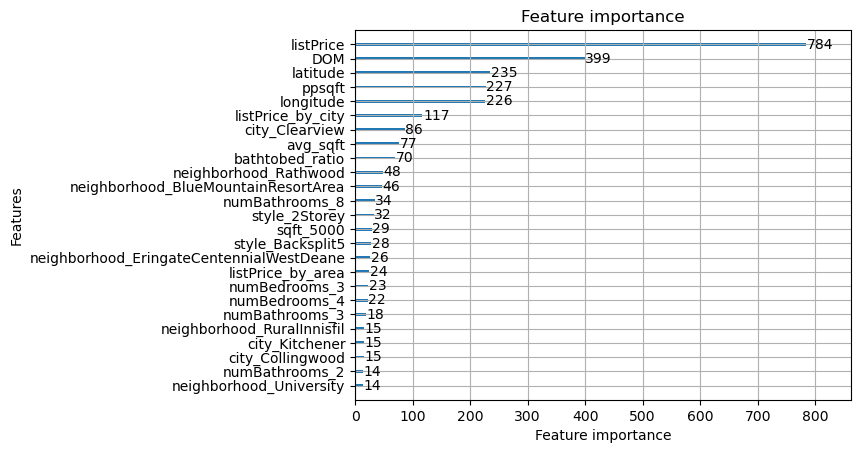

In [44]:
lgbm.plot_importance(base_regressor.fit(x_train,y_train), max_num_features = 25)